In [1]:
import pandas as pd

data = pd.read_csv("train.csv")
data.head()
data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [2]:
print(data.isna().sum())
print(data.dtypes)
data.value_counts()
data.columns
print(data.head())

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64
id                    int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object
   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc         7.91              98.8              no   
1   1   18   other  diploma         4.95              94.8             yes   
2   2   20  female     b.sc         4.68              92.6             yes   
3   3   19 

Medir skewness dos dados numéricos
Conclusão: os dados são bastantes simétricos, loogo a skewness não oferece muita informação

In [3]:
data= data.drop(columns="id")
skewness = data.skew(numeric_only=True)
print(skewness)

age                -0.023878
study_hours         0.008931
class_attendance   -0.095832
sleep_hours        -0.039986
exam_score         -0.048273
dtype: float64


Medir kurtosis dos dados numéricos: Podemos concluir que os dados são bastante achatados pois tdos os valores são menores que 0

In [4]:
kurtosis = data.kurt(numeric_only=True)
print(kurtosis)

age                -1.204216
study_hours        -1.211528
class_attendance   -1.189059
sleep_hours        -1.222221
exam_score         -0.618958
dtype: float64


Distribuição das nt

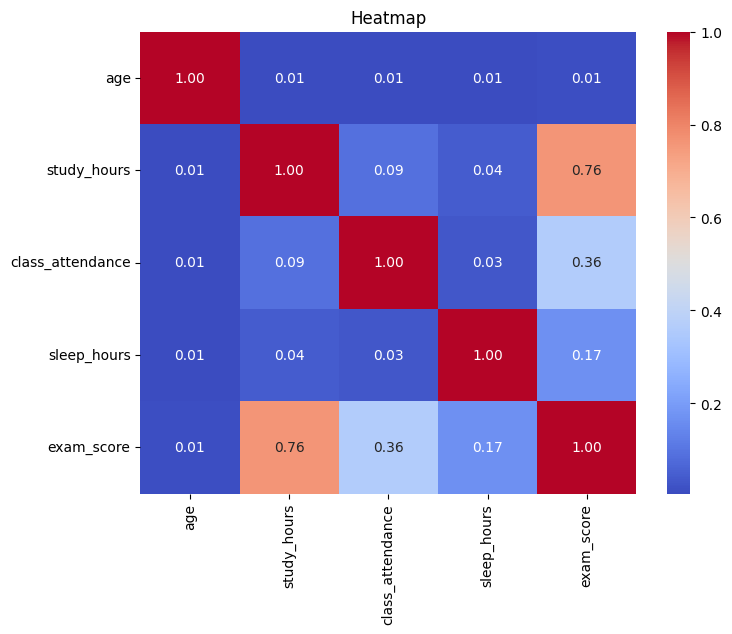

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Heatmap")
plt.show()

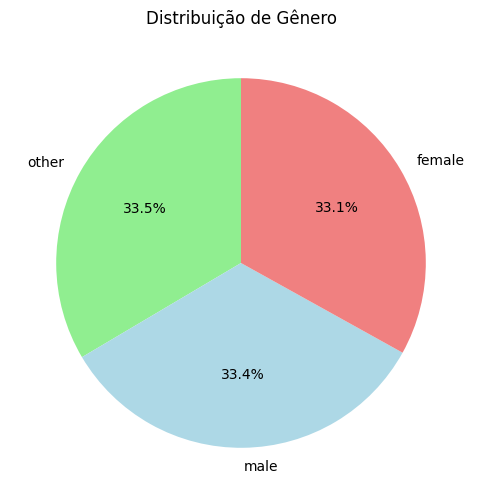

In [6]:
gender_counts = data['gender'].value_counts() # nums para piechart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors = ["lightgreen", "lightblue", "lightcoral"]
)
plt.title("Distribuição de Gênero")
plt.show()

In [7]:
def categorize_data(df):
    df_copy = df.copy()

    # Idade
    df_copy['age_interval'] = pd.cut(df_copy['age'],
                                     bins=[17,19,21,23,25,100],
                                     labels=["18-19","20-21","22-23","24-25","26+"])

    # Horas de estudo
    df_copy['study_hours_interval'] = pd.cut(df_copy['study_hours'],
                                             bins=[-1,1,3,5,7,100],
                                             labels=["0-1h","2-3h","4-5h","6-7h","8h ou mais"])

    # Presença em aula
    df_copy['class_attendance_interval'] = pd.cut(df_copy['class_attendance'],
                                                  bins=[-1,20,40,60,80,100],
                                                  labels=["0-20%","21-40%","41-60%","61-80%","81-100%"])

    # Horas de sono
    df_copy['sleep_hours_interval'] = pd.cut(df_copy['sleep_hours'],
                                             bins=[-1,4,6,8,10,100],
                                             labels=["0-4h","5-6h","7-8h","9-10h","11h ou mais"])

    # Nota do exame
    df_copy['exam_score_interval'] = pd.cut(df_copy['exam_score'],
                                            bins=[-1,49,59,69,79,89,100],
                                            labels=["0-49","50-59","60-69","70-79","80-89","90-100"])
    return df_copy

# Aplicando a função
data_intervals = categorize_data(data)

# Visualizando o resultado
print(data_intervals.head())

   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc         7.91              98.8              no   
1   18   other  diploma         4.95              94.8             yes   
2   20  female     b.sc         4.68              92.6             yes   
3   19    male     b.sc         2.00              49.5             yes   
4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score age_interval study_hours_interval class_attendance_interval  \
0  

C:\Users\maria\AppData\Local\Temp\ipykernel_27040\3874816542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


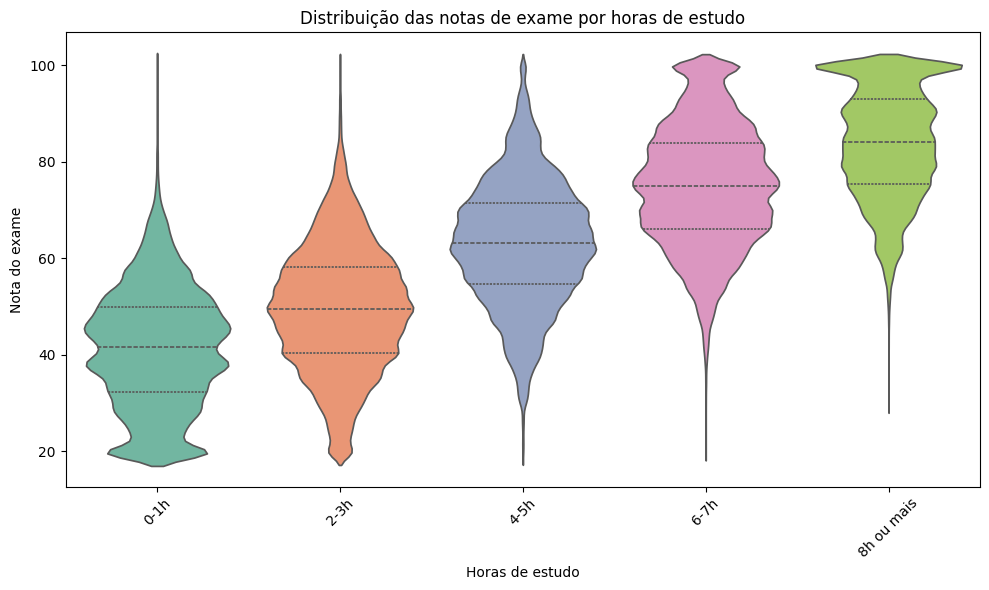

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Certifique-se de que as colunas de intervalos já existem
# 'study_hours_interval' e 'exam_score_interval' do passo anterior

plt.figure(figsize=(10,6))
sns.violinplot(
    x="study_hours_interval",       # usando intervalos de horas de estudo
    y="exam_score",                 
    data=data_intervals,
    inner="quartile",             
    palette="Set2"
)
plt.title("Distribuição das notas de exame por horas de estudo")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota do exame")
plt.xticks(rotation=45)             # gira os rótulos do eixo x para melhor visualização
plt.tight_layout()
plt.show()

Lolipop Chart

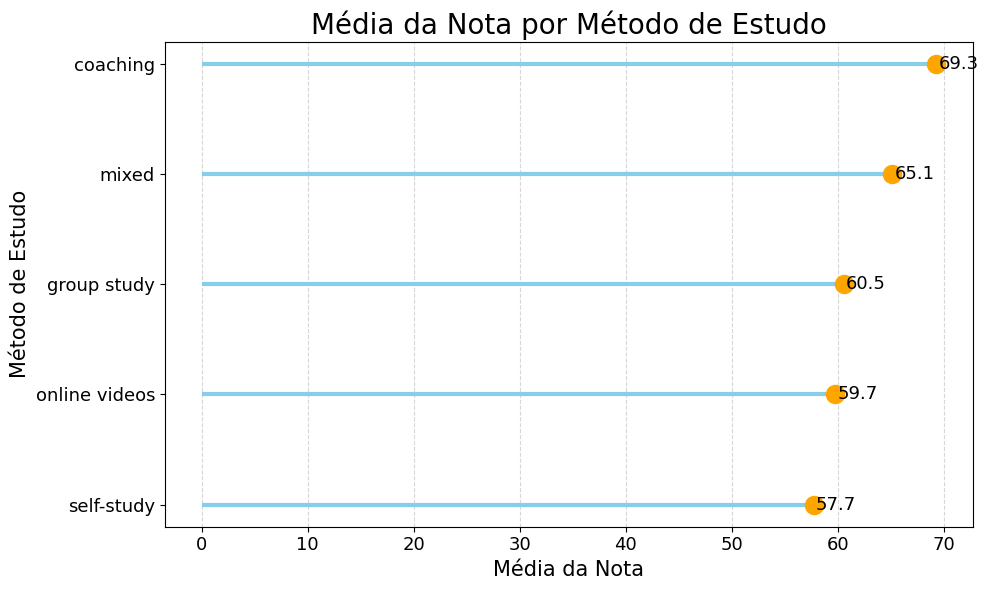

In [9]:
import matplotlib.pyplot as plt

media_metodo = data_intervals.groupby("study_method")["exam_score"].mean().sort_values()

plt.figure(figsize=(10, 6))

plt.hlines(y=media_metodo.index, xmin=0, xmax=media_metodo.values, color='skyblue', linewidth=3)
plt.plot(media_metodo.values, media_metodo.index, "o", color='orange', markersize=13)

# Valores ao lado do ponto
for i, v in enumerate(media_metodo.values):
    plt.text(v + 0.2, i, f"{v:.1f}", va='center', fontsize=13)

plt.xlabel("Média da Nota", size = 15)
plt.ylabel("Método de Estudo", size=15)
plt.title("Média da Nota por Método de Estudo", size=20)
plt.xticks(fontsize=13)  # números do eixo X
plt.yticks(fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Spider chart

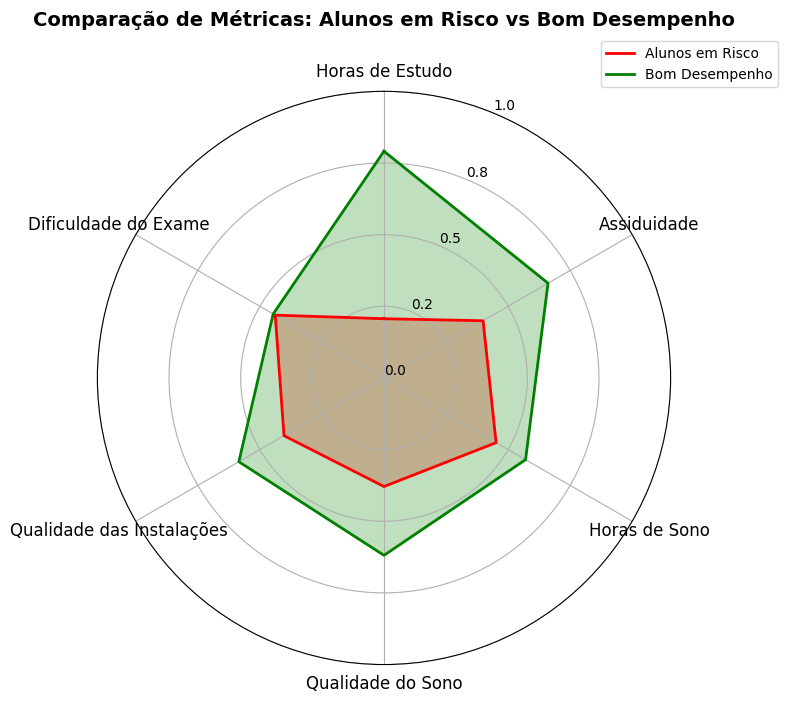

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Function to map categorical variables to numeric
def encode_categories(df):
    sleep_quality_map = {'poor': 1, 'average': 2, 'good': 3}
    exam_difficulty_map = {'easy': 1, 'moderate': 2, 'hard': 3}
    facility_rating_map = {'low': 1, 'medium': 2, 'high': 3}
    
    df['sleep_quality_num'] = df['sleep_quality'].map(sleep_quality_map)
    df['exam_difficulty_num'] = df['exam_difficulty'].map(exam_difficulty_map)
    df['facility_rating_num'] = df['facility_rating'].map(facility_rating_map)
    
    return df

# Copy dataframe
df = data_intervals.copy()

# Encode categorical variables
df = encode_categories(df)

# Metrics
metrics = [
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'sleep_quality_num',
    'facility_rating_num',
    'exam_difficulty_num'
]

# Normalizar os dados (ESSENCIAL para radar)
scaler = MinMaxScaler()
df[metrics] = scaler.fit_transform(df[metrics])

# Definir grupos
aluno_risco = df[df['exam_score'] < 50]
bom_desempenho = df[df['exam_score'] >= 75]

# Médias
mean_risco = aluno_risco[metrics].mean().fillna(0)
mean_bom = bom_desempenho[metrics].mean().fillna(0)

# Preparar radar
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # fechar círculo

mean_risco_values = mean_risco.tolist()
mean_risco_values += mean_risco_values[:1]

mean_bom_values = mean_bom.tolist()
mean_bom_values += mean_bom_values[:1]

labels_map = {
    'study_hours': 'Horas de Estudo',
    'class_attendance': 'Assiduidade',
    'sleep_hours': 'Horas de Sono',
    'sleep_quality_num': 'Qualidade do Sono',
    'facility_rating_num': 'Qualidade das Instalações',
    'exam_difficulty_num': 'Dificuldade do Exame'
}
# Plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Ajustes do eixo
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Plot risco
ax.plot(angles, mean_risco_values, color='red', linewidth=2, label='Alunos em Risco')
ax.fill(angles, mean_risco_values, color='red', alpha=0.25)

# Plot bom desempenho
ax.plot(angles, mean_bom_values, color='green', linewidth=2, label='Bom Desempenho')
ax.fill(angles, mean_bom_values, color='green', alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([labels_map[m] for m in metrics], fontsize=12)

# Escala fixa (0–1 por causa da normalização)
ax.set_yticks(np.linspace(0, 1, 5))
ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0, 1, 5)], fontsize=10)
ax.set_ylim(0, 1)

# Título e legenda
plt.title(
    "Comparação de Métricas: Alunos em Risco vs Bom Desempenho",
    fontsize=14,
    fontweight='bold',
    y=1.1
)

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


Identificação de Outliers

In [11]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import pandas as pd

cols = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
lof_df = data_intervals[cols].copy()
# NORMALIZAR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lof_df)

# aplicar LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_scaled)

# adicionar resultados
lof_df["outlier"] = y_pred
lof_df["lof_score"] = lof.negative_outlier_factor_

# filtrar outliers
outliers = lof_df[lof_df["outlier"] == -1]

# outputs
print("Número de outliers:", len(outliers))
print("\nOutliers encontrados:\n")
print(outliers.sort_values(by="lof_score"))  # mais extremos primeiro

Número de outliers: 31500

Outliers encontrados:

        age  study_hours  class_attendance  sleep_hours  exam_score  outlier  \
258607   17         0.80              65.3          9.5        99.9       -1   
615603   19         0.89              67.8          4.3        92.7       -1   
47775    17         0.75              89.4          4.1        88.8       -1   
497661   24         6.81              40.6          4.1        25.0       -1   
560007   17         7.44              97.6          6.4        47.8       -1   
...     ...          ...               ...          ...         ...      ...   
479077   18         1.52              99.4          5.2        42.7       -1   
578425   21         3.17              71.0          4.1        32.4       -1   
182527   18         2.20              92.5          6.2        80.8       -1   
549132   21         6.05              64.7          8.2        53.5       -1   
74684    18         2.62              71.6          6.3        34.4   

In [12]:
print(data_intervals.describe().round(2))
data_intervals.dtypes
data_intervals.head()
data_intervals.columns

             age  study_hours  class_attendance  sleep_hours  exam_score
count  630000.00    630000.00         630000.00    630000.00   630000.00
mean       20.55         4.00             71.99         7.07       62.51
std         2.26         2.36             17.43         1.74       18.92
min        17.00         0.08             40.60         4.10       19.60
25%        19.00         1.97             57.00         5.60       48.80
50%        21.00         4.00             72.60         7.10       62.60
75%        23.00         6.05             87.20         8.60       76.30
max        24.00         7.91             99.40         9.90      100.00


Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score', 'age_interval',
       'study_hours_interval', 'class_attendance_interval',
       'sleep_hours_interval', 'exam_score_interval'],
      dtype='object')

In [13]:
data_intervals.duplicated().sum()

np.int64(0)

Multicolinearidade

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data_intervals[cols].drop(columns="exam_score")
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

            feature        VIF
0               age  25.059881
1       study_hours   3.870725
2  class_attendance  15.892231
3       sleep_hours  15.271241


Teste de independencia para variaveis categóricas


In [15]:
from scipy.stats import chi2_contingency

categorical_cols = ['gender', 'course', 'study_method', 'internet_access']
for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        contingency = pd.crosstab(data_intervals[categorical_cols[i]],
                                  data_intervals[categorical_cols[j]])
        chi2, p, _, _ = chi2_contingency(contingency)
        print(f"{categorical_cols[i]} vs {categorical_cols[j]}: p-value = {p:.4f}")

gender vs course: p-value = 0.0000
gender vs study_method: p-value = 0.0000
gender vs internet_access: p-value = 0.0583
course vs study_method: p-value = 0.0000
course vs internet_access: p-value = 0.0002
study_method vs internet_access: p-value = 0.0000


Como vif > 5 para todas, existe alta multicolinearidade, algo a ter em conta nos modelos de previsão

Identificar desequilíbrios nas variáveis categóricas

In [16]:
categorical_cols = ['gender', 'course', 'study_method', 'internet_access']

for col in categorical_cols:
    print(f"=== {col} ===")
    print(data_intervals[col].value_counts())            # contagem absoluta
    print(data_intervals[col].value_counts(normalize=True))  # percentual
    print("\n")

=== gender ===
gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
gender
other     0.335075
male      0.334275
female    0.330651
Name: proportion, dtype: float64


=== course ===
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
course
b.tech     0.208311
b.sc       0.177070
b.com      0.176083
bca        0.140827
bba        0.120070
ba         0.098395
diploma    0.079244
Name: proportion, dtype: float64


=== study_method ===
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
study_method
coaching         0.209043
self-study       0.208144
mixed            0.195375
group study      0.195252
online videos    0.192186
Name: proportion, dtype: float64


=== internet_access ===
internet_access
yes    579423
no      50577
Name: count, dtype: 

C:\Users\maria\AppData\Local\Temp\ipykernel_27040\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


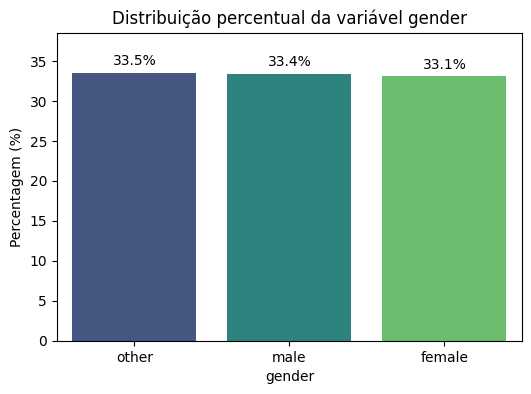

C:\Users\maria\AppData\Local\Temp\ipykernel_27040\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


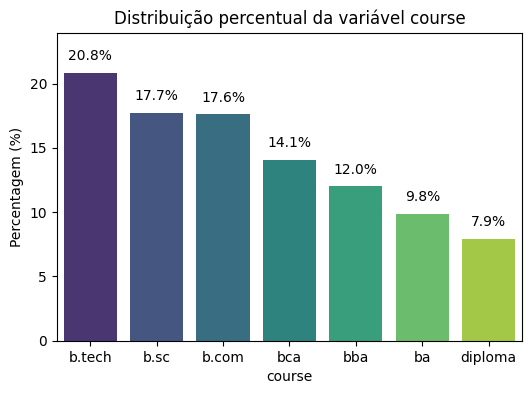

C:\Users\maria\AppData\Local\Temp\ipykernel_27040\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


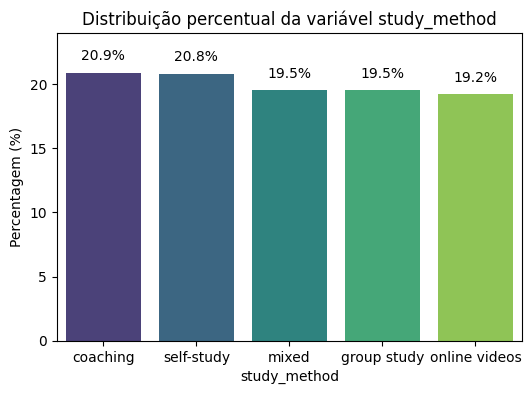

C:\Users\maria\AppData\Local\Temp\ipykernel_27040\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


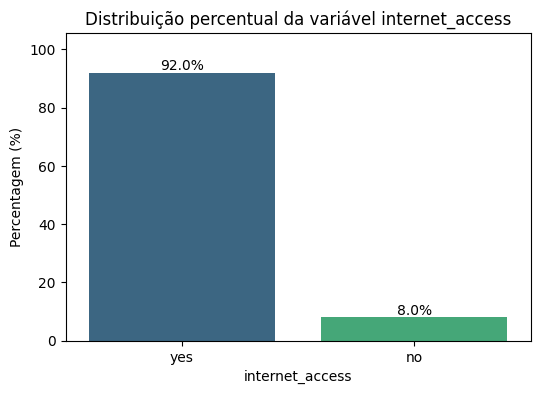

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['gender', 'course', 'study_method', 'internet_access']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    
    # Calcular porcentagem
    counts = data_intervals[col].value_counts(normalize=True) * 100
    
    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    
    # Adicionar labels em porcentagem
    for i, val in enumerate(counts.values):
        plt.text(i, val + 1, f"{val:.1f}%", ha='center')
    
    plt.ylabel("Percentagem (%)")
    plt.title(f"Distribuição percentual da variável {col}")
    plt.ylim(0, max(counts.values)*1.15)  # deixar espaço para labels
    plt.show()
    

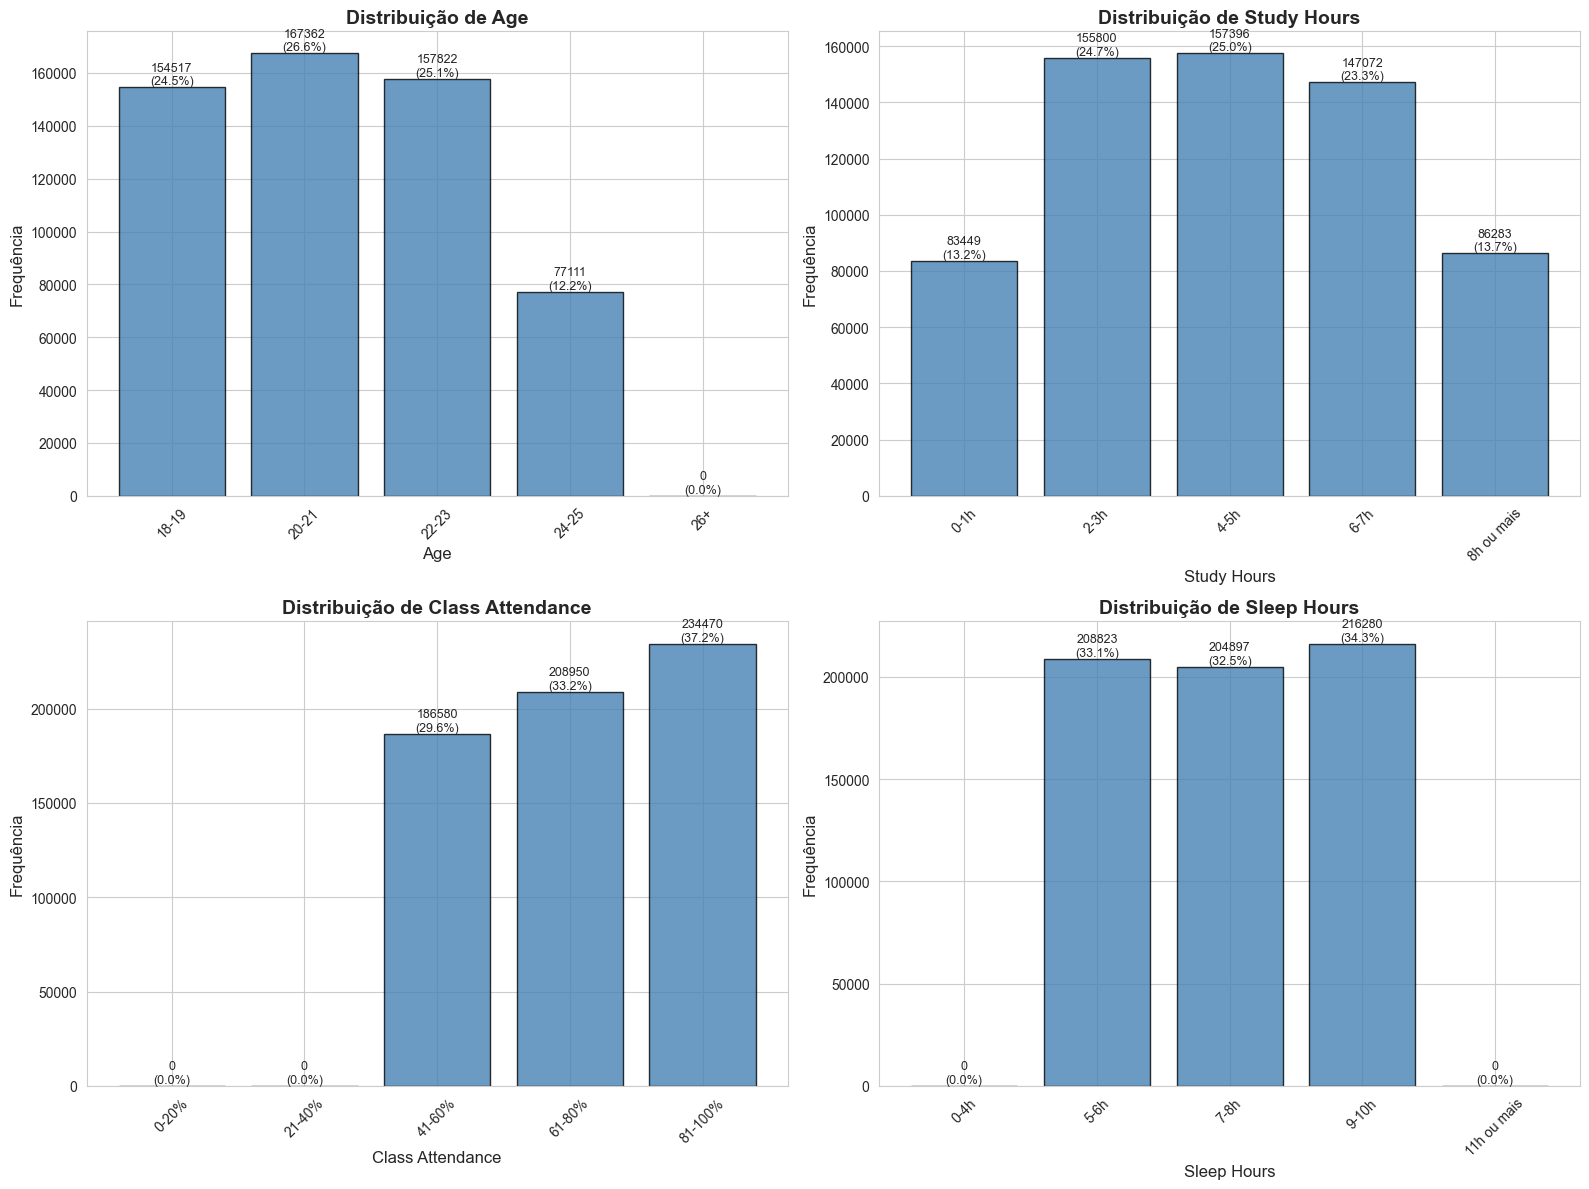

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Lista das variáveis intervalares (excluindo exam_score_interval)
interval_vars = [
    'age_interval', 
    'study_hours_interval', 
    'class_attendance_interval',
    'sleep_hours_interval'
]

# Criar subplots para visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(interval_vars):
    # Calcular contagens e percentagens
    counts = data_intervals[var].value_counts().sort_index()
    percentages = (counts / len(data_intervals)) * 100
    
    # Gráfico de barras
    bars = axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.8)
    
    # Título sem a palavra "interval"
    title = var.replace('_interval', '').replace('_', ' ').title()
    axes[i].set_title(f'Distribuição de {title}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(title, fontsize=12)
    axes[i].set_ylabel('Frequência', fontsize=12)
    
    # Adicionar percentagens no topo das barras
    for bar, count, pct in zip(bars, counts.values, percentages.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    
    # Rotacionar labels do eixo x se necessário
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Pré processamento

Passos comuns a todas as etapas

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

### Pré processamento para regressão


In [20]:
# remover os outliers
outliers_index = lof_df[lof_df["outlier"] == -1].index
data_reg = data.copy()
data_reg = data.drop(index = outliers_index)
#print(len(data_reg))
data_reg_cat = data_reg.copy()
data_reg_cat["internet_access"] = data_reg_cat["internet_access"].str.strip().str.lower().map({"yes":1, "no":0})
print(data_reg_cat)

        age  gender  course  study_hours  class_attendance  internet_access  \
3        19    male    b.sc         2.00              49.5                1   
4        23    male     bca         7.65              86.9                1   
5        24    male   b.com         5.04              85.1                1   
6        20    male    b.sc         4.28              87.0                0   
7        22  female      ba         4.19              44.9                1   
...     ...     ...     ...          ...               ...              ...   
629994   20    male   b.com         1.67              73.7                1   
629995   18  female  b.tech         4.86              70.7                1   
629996   21  female      ba         7.08              54.4                1   
629997   24    male     bca         0.64              44.2                1   
629998   20    male   b.com         1.54              75.1                1   

        sleep_hours sleep_quality   study_method fa

para variáveis categóricas com ordem

In [21]:
# sleep_quality facility_rating
print(data_reg_cat["sleep_quality"].unique())
print(data_reg_cat["facility_rating"].unique())
print(data_reg_cat["exam_difficulty"].unique())  # se aplicar exam_map

['average' 'good' 'poor']
['high' 'medium' 'low']
['moderate' 'easy' 'hard']


In [22]:
data_reg_cat["sleep_quality_clean"] = (
    data_reg_cat["sleep_quality"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data_reg_cat["facility_rating_clean"] = (
    data_reg_cat["facility_rating"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data_reg_cat["exam_difficulty_clean"] = (
    data_reg_cat["exam_difficulty"]
    .astype(str)
    .str.strip()
    .str.lower()
)


sleep_map = {"poor": 0, "average": 1, "good": 2}
facility_map = {"low": 0, "medium": 1, "high": 2}
exam_map = {"easy": 0, "moderate": 1, "hard": 2}

data_reg_cat["sleep_quality_mapped"] = data_reg_cat["sleep_quality_clean"].map(sleep_map)
data_reg_cat["facility_rating_mapped"] = data_reg_cat["facility_rating_clean"].map(facility_map)
data_reg_cat["exam_difficulty_mapped"] = data_reg_cat["exam_difficulty_clean"].map(exam_map)

data_reg_cat["sleep_quality_mapped"] = data_reg_cat["sleep_quality_mapped"].fillna(-1)
data_reg_cat["facility_rating_mapped"] = data_reg_cat["facility_rating_mapped"].fillna(-1)
data_reg_cat["exam_difficulty_mapped"] = data_reg_cat["exam_difficulty_mapped"].fillna(-1)

print(
    data_reg_cat[
        [
            "sleep_quality", "sleep_quality_mapped",
            "facility_rating", "facility_rating_mapped",
            "exam_difficulty", "exam_difficulty_mapped"
        ]
    ].head()
)

  sleep_quality  sleep_quality_mapped facility_rating  facility_rating_mapped  \
3       average                     1            high                       2   
4          good                     2            high                       2   
5       average                     1          medium                       1   
6       average                     1            high                       2   
7          good                     2            high                       2   

  exam_difficulty  exam_difficulty_mapped  
3        moderate                       1  
4            easy                       0  
5        moderate                       1  
6        moderate                       1  
7            hard                       2  


In [23]:
# colunas mapeadas
cols_mapped = [col for col in data_reg_cat.columns if col.endswith("_mapped")]

# colunas que NÃO sofreram alterações (exclui as _clean)
cols_original = [col for col in data_reg_cat.columns if not col.endswith("_clean") and not col.endswith("_mapped")]

# novo dataframe final
data_reg_final = data_reg_cat[cols_original + cols_mapped]
data_reg_final = data_reg_final.drop(columns=["sleep_quality", "facility_rating","exam_difficulty"])
data_reg_final.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,study_method,exam_score,sleep_quality_mapped,facility_rating_mapped,exam_difficulty_mapped
3,19,male,b.sc,2.00,49.5,1,8.3,group study,63.9,1,2,1
4,23,male,bca,7.65,86.9,1,9.6,self-study,100.0,2,2,0
5,24,male,b.com,5.04,85.1,1,9.4,online videos,70.1,1,1,1
6,20,male,b.sc,4.28,87.0,0,9.1,mixed,63.4,1,2,1
7,22,female,ba,4.19,44.9,1,8.8,self-study,76.8,2,2,2


In [24]:
# limpar
data_reg_cat["study_method_clean"] = (
    data_reg_cat["study_method"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# one-hot encoding (com drop_first)
study_dummies = pd.get_dummies(
    data_reg_cat["study_method_clean"],
    prefix="study_method",
    drop_first=True
).astype(int)

course_dummies = pd.get_dummies(
    data_reg_cat["course"],
    prefix="course",
    drop_first=True
).astype(int)

# juntar
data_reg_final = pd.concat(
    [data_reg_final, study_dummies, course_dummies],
    axis=1
)
# limpar
data_reg_cat["gender_clean"] = (
    data_reg_cat["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# one-hot encoding
gender_dummies = pd.get_dummies(
    data_reg_cat["gender_clean"],
    prefix="gender",
    drop_first=True
).astype(int)

# juntar ao dataframe final
data_reg_final = pd.concat(
    [data_reg_final, gender_dummies],
    axis=1
)

# remover coluna original
data_reg_final = data_reg_final.drop(
    columns=["gender"],
    errors="ignore"
)

data_reg_final.head()

data_reg_final.describe()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,sleep_quality_mapped,facility_rating_mapped,exam_difficulty_mapped,study_method_group study,...,study_method_online videos,study_method_self-study,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,gender_male,gender_other
count,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,...,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000
mean,20.546468,4.009131,72.064617,0.919684,7.073758,62.572685,1.000149,0.984927,0.877519,0.196837,...,0.192581,0.207352,0.177133,0.208573,0.098232,0.119753,0.140665,0.078949,0.334508,0.335033
std,2.258987,2.360262,17.349004,0.271782,1.736774,18.641635,0.820929,0.811078,0.650715,0.397608,...,0.394327,0.405410,0.381781,0.406289,0.297629,0.324672,0.347676,0.269659,0.471819,0.472002
min,17.000000,0.080000,40.600000,0.000000,4.100000,19.599000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.970000,57.200000,1.000000,5.600000,49.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.000000,4.010000,72.600000,1.000000,7.100000,62.600000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.000000,6.060000,87.200000,1.000000,8.600000,76.100000,2.000000,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,24.000000,7.910000,99.400000,1.000000,9.900000,100.000000,2.000000,2.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


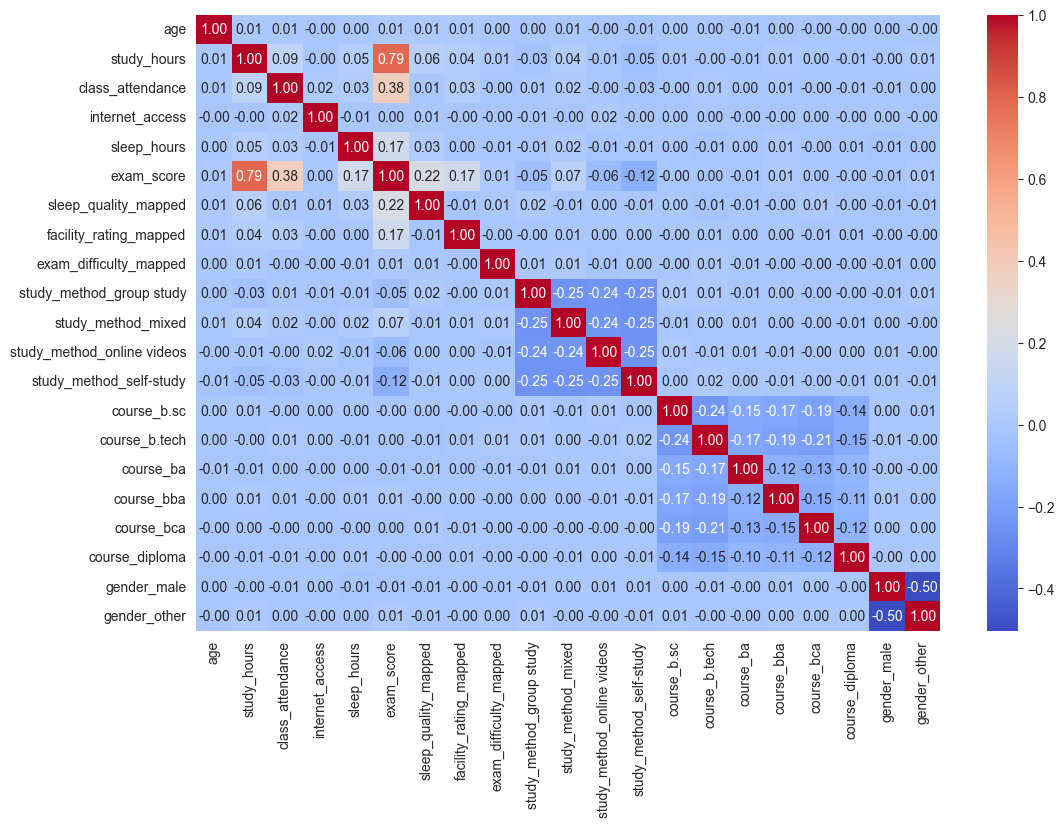

In [25]:
numeric_cols = data_reg_final.select_dtypes(include=["float64", "int64"]).columns
corr = data_reg_final[numeric_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

Valores Significativos na correlação abs maior que 0.1

In [ ]:
corr = data_reg_final.corr()

# Depois selecione correlações com exam_score
corr_exam = corr["exam_score"]
selected_features = corr_exam[corr_exam.abs() >= 0.1].index
selected_features = selected_features.drop("exam_score", errors="ignore")

print(selected_features)
# criar df
df_final = data_reg_final[list(selected_features) + ["exam_score"]]
df_final.head()

Index(['study_hours', 'class_attendance', 'sleep_hours',
       'sleep_quality_mapped', 'facility_rating_mapped',
       'study_method_self-study'],
      dtype='object')


,study_hours,class_attendance,sleep_hours,sleep_quality_mapped,facility_rating_mapped,study_method_self-study,exam_score
3,2.00,49.5,8.3,1,2,0,63.9
4,7.65,86.9,9.6,2,2,1,100.0
5,5.04,85.1,9.4,1,1,0,70.1
6,4.28,87.0,9.1,1,2,0,63.4
7,4.19,44.9,8.8,2,2,1,76.8


Criação de atributos

In [ ]:
import numpy as np
import pandas as pd

df = df_final.copy()

df["total_study_time"] = df["study_hours"] + df["class_attendance"]

df["sleep_balance"] = df["sleep_hours"] * df["sleep_quality_mapped"]

df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1) # +1 para evitar soma por zero

df["log_study_hours"] = np.log1p(df["study_hours"])

df["study_hours_squared"] = df["study_hours"] ** 2

df["study_attendance_interaction"] = df["study_hours"] * df["class_attendance"]

df["sleep_quality_effect"] = df["sleep_hours"] * df["sleep_quality_mapped"]

df["study_vs_sleep"] = df["study_hours"] / (df["sleep_hours"] + 1)
# ver quais têm correlação superior a 0.1 em valor abs

corr = df.corr(numeric_only=True)

corr_exam = corr["exam_score"]

selected_features = corr_exam[corr_exam.abs() >= 0.1].index

selected_features = selected_features.drop("exam_score", errors="ignore")

print(selected_features)


df_final = df[list(selected_features) + ["exam_score"]]

df_final.head()

Features selecionadas:
Index(['study_hours', 'class_attendance', 'sleep_hours',
       'sleep_quality_mapped', 'facility_rating_mapped',
       'study_method_self-study', 'total_study_time', 'sleep_balance',
       'study_sleep_ratio', 'log_study_hours', 'study_hours_squared',
       'study_attendance_interaction', 'sleep_quality_effect',
       'study_vs_sleep'],
      dtype='object')


,study_hours,class_attendance,sleep_hours,sleep_quality_mapped,facility_rating_mapped,study_method_self-study,total_study_time,sleep_balance,study_sleep_ratio,log_study_hours,study_hours_squared,study_attendance_interaction,sleep_quality_effect,study_vs_sleep,exam_score
3,2.00,49.5,8.3,1,2,0,51.50,8.3,0.215054,1.098612,4.0000,99.000,8.3,0.215054,63.9
4,7.65,86.9,9.6,2,2,1,94.55,19.2,0.721698,2.157559,58.5225,664.785,19.2,0.721698,100.0
5,5.04,85.1,9.4,1,1,0,90.14,9.4,0.484615,1.798404,25.4016,428.904,9.4,0.484615,70.1
6,4.28,87.0,9.1,1,2,0,91.28,9.1,0.423762,1.663926,18.3184,372.360,9.1,0.423762,63.4
7,4.19,44.9,8.8,2,2,1,49.09,17.6,0.427551,1.646734,17.5561,188.131,17.6,0.427551,76.8


Verificar novamente VIF

In [69]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# copiar dataframe
df2 = data_reg_final.copy()

# manter apenas variáveis numéricas
df_num = df2.select_dtypes(include=['number'])

# adicionar constante
X = sm.add_constant(df_num)

# calcular VIF
vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

print(vif_df)

                      Variável         VIF
0                        const  143.627780
1                          age    1.000447
2                  study_hours    3.765584
3             class_attendance    1.457900
4              internet_access    1.000725
5                  sleep_hours    1.083751
6                   exam_score    5.109168
7         sleep_quality_mapped    1.154372
8       facility_rating_mapped    1.098931
9       exam_difficulty_mapped    1.000935
10    study_method_group study    1.667896
11          study_method_mixed    1.608533
12  study_method_online videos    1.683306
13     study_method_self-study    1.748642
14                 course_b.sc    1.648912
15               course_b.tech    1.728065
16                   course_ba    1.403699
17                  course_bba    1.477555
18                  course_bca    1.543748
19              course_diploma    1.333121
20                 gender_male    1.340443
21                gender_other    1.340415


### Multicolinearidade: Criação de variáveis

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = encode_categories(data)
for col in ["sleep_quality", "exam_difficulty", "facility_rating"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

#remoção da coluna age
df = df.drop(columns=["age"])

# regressão: class_attendance ~ study_hours
X = sm.add_constant(df["study_hours"])
y = df["class_attendance"]
model = sm.OLS(y, X).fit()

#criação da nova variável e remoção da variável anterior
df["attendance_residual"] = model.resid
df = df.drop(columns=["class_attendance"])

#recálculo do VIF
features_vif = ["study_hours","attendance_residual","sleep_quality_num"]
X_vif = sm.add_constant(df[features_vif])
vif_df = pd.DataFrame({
    "Variável": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])]
})

print(df.head())
print(vif_df)

   gender   course  study_hours internet_access  sleep_hours sleep_quality  \
0  female     b.sc         7.91              no          4.9       average   
1   other  diploma         4.95             yes          4.7          poor   
2  female     b.sc         4.68             yes          5.8          poor   
3    male     b.sc         2.00             yes          8.3       average   
4    male      bca         7.65             yes          9.6          good   

    study_method facility_rating exam_difficulty  exam_score  \
0  online videos             low            easy        78.3   
1     self-study          medium        moderate        46.7   
2       coaching            high        moderate        99.0   
3    group study            high        moderate        63.9   
4     self-study            high            easy       100.0   

   sleep_quality_num  exam_difficulty_num  facility_rating_num  \
0                  2                    1                    1   
1             

In [ ]:
data["study_effort"] = data["study_hours"] * data["class_attendance"]
data["rest_balance"] = data["sleep_hours"] * data["sleep_quality_num"]
data["study_access"] = data["study_hours"] * data["internet_access_num"]
data["study_difficulty"] = data["study_hours"] * data["exam_difficulty_num"]

Normalização

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_normal = scaler.fit_transform(df)

ValueError: could not convert string to float: 'female'